# Sound Classification 3

CNN model based on mel-spectrograms. This notebook combines UrbanSound8K and ESC-50 into 6 target classes:

- transport
- human
- alert
- building_noise
- animals
- others

In [1]:
import json
import os
from pathlib import Path

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

layers = tf.keras.layers
models = tf.keras.models
to_categorical = tf.keras.utils.to_categorical

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [2]:
URBAN_AUDIO_DIR = Path("UrbanSound8K/audio")
URBAN_METADATA_PATH = Path("UrbanSound8K/metadata/UrbanSound8K.csv")

ESC_AUDIO_DIR = Path("ESC-50-master/audio")
ESC_METADATA_PATH = Path("ESC-50-master/meta/esc50.csv")

ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

SAMPLE_RATE = 16000
DURATION = 5
SAMPLES = SAMPLE_RATE * DURATION

N_MELS = 128
MAX_LEN = 157

CLASS_NAMES = [
    "transport",
    "human",
    "alert",
    "building_noise",
    "animals",
    "others",
]

CLASS_TO_ID = {name: idx for idx, name in enumerate(CLASS_NAMES)}
ID_TO_CLASS = {idx: name for name, idx in CLASS_TO_ID.items()}
NUM_CLASSES = len(CLASS_NAMES)

CLASS_TO_ID

{'transport': 0,
 'human': 1,
 'alert': 2,
 'building_noise': 3,
 'animals': 4,
 'others': 5}

In [3]:
URBAN_CLASS_MAP = {
    "engine_idling": "transport",
    "car_horn": "transport",
    "children_playing": "human",
    "street_music": "human",
    "siren": "alert",
    "gun_shot": "alert",
    "drilling": "building_noise",
    "jackhammer": "building_noise",
    "dog_bark": "animals",
    "air_conditioner": "others",
}

ESC_CLASS_MAP = {
    # transport
    "airplane": "transport",
    "car_horn": "transport",
    "engine": "transport",
    "helicopter": "transport",
    "train": "transport",

    # human
    "breathing": "human",
    "brushing_teeth": "human",
    "clapping": "human",
    "coughing": "human",
    "crying_baby": "human",
    "drinking_sipping": "human",
    "footsteps": "human",
    "laughing": "human",
    "sneezing": "human",
    "snoring": "human",

    # alert
    "church_bells": "alert",
    "clock_alarm": "alert",
    "fireworks": "alert",
    "glass_breaking": "alert",
    "siren": "alert",

    # building and tool noise
    "chainsaw": "building_noise",
    "hand_saw": "building_noise",
    "vacuum_cleaner": "building_noise",
    "washing_machine": "building_noise",

    # animals
    "cat": "animals",
    "chirping_birds": "animals",
    "cow": "animals",
    "crickets": "animals",
    "crow": "animals",
    "dog": "animals",
    "frog": "animals",
    "hen": "animals",
    "insects": "animals",
    "pig": "animals",
    "rooster": "animals",
    "sheep": "animals",
}

def map_esc_category(category):
    return ESC_CLASS_MAP.get(category, "others")

In [5]:
def load_urbansound8k():
    metadata = pd.read_csv(URBAN_METADATA_PATH)
    rows = []

    for _, row in metadata.iterrows():
        original_label = row["class"]
        target_label = URBAN_CLASS_MAP.get(original_label, "others")
        file_path = URBAN_AUDIO_DIR / f"fold{row['fold']}" / row["slice_file_name"]

        rows.append({
            "file_path": str(file_path),
            "source": "UrbanSound8K",
            "source_fold": int(row["fold"]),
            "original_label": original_label,
            "target_label": target_label,
        })

    return pd.DataFrame(rows)


def load_esc50():
    metadata = pd.read_csv(ESC_METADATA_PATH)
    rows = []

    for _, row in metadata.iterrows():
        original_label = row["category"]
        target_label = map_esc_category(original_label)
        file_path = ESC_AUDIO_DIR / row["filename"]

        rows.append({
            "file_path": str(file_path),
            "source": "ESC-50",
            "source_fold": int(row["fold"]),
            "original_label": original_label,
            "target_label": target_label,
        })

    return pd.DataFrame(rows)


urban_df = load_urbansound8k()
esc_df = load_esc50()
dataset_df = pd.concat([urban_df, esc_df], ignore_index=True)
dataset_df["label_id"] = dataset_df["target_label"].map(CLASS_TO_ID)

print("Total files:", len(dataset_df))
display(dataset_df.head())
display(dataset_df.groupby(["source", "target_label"]).size().unstack(fill_value=0))
display(dataset_df["target_label"].value_counts())

Total files: 10743


,file_path,source,source_fold,original_label,target_label,label_id
0,UrbanSound8K\audio\fold5\100032-3-0-0.wav,UrbanSound8K,5,dog_bark,animals,4
1,UrbanSound8K\audio\fold5\100263-2-0-117.wav,UrbanSound8K,5,children_playing,human,1
2,UrbanSound8K\audio\fold5\100263-2-0-121.wav,UrbanSound8K,5,children_playing,human,1
3,UrbanSound8K\audio\fold5\100263-2-0-126.wav,UrbanSound8K,5,children_playing,human,1
4,UrbanSound8K\audio\fold5\100263-2-0-137.wav,UrbanSound8K,5,children_playing,human,1


target_label,alert,animals,building_noise,human,others,transport
source,,,,,,
ESC-50,200,480,160,400,560,200
UrbanSound8K,1303,1000,2000,2011,1000,1429


target_label
human             2411
building_noise    2160
transport         1629
others            1560
alert             1503
animals           1480
Name: count, dtype: int64

In [6]:
missing_files = dataset_df[~dataset_df["file_path"].map(lambda path: Path(path).exists())]

print("Missing files:", len(missing_files))
display(missing_files.head())

Missing files: 0


,file_path,source,source_fold,original_label,target_label,label_id


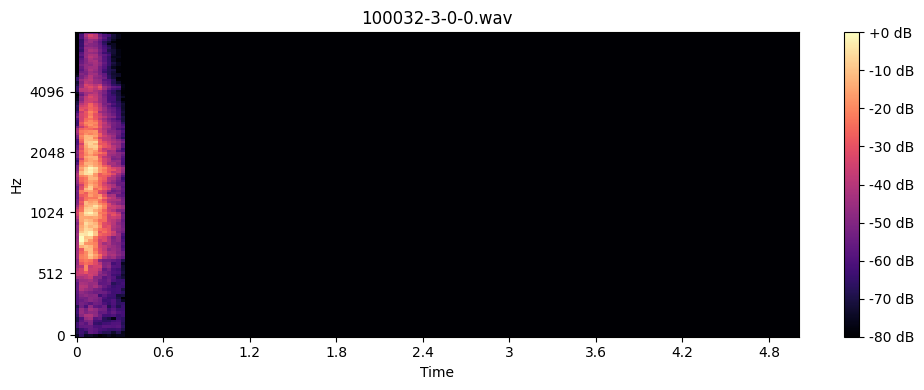

In [7]:
def extract_mel(file_path):
    y, sr = librosa.load(file_path, sr=SAMPLE_RATE, mono=True)

    if len(y) < SAMPLES:
        y = np.pad(y, (0, SAMPLES - len(y)), mode="constant")
    else:
        y = y[:SAMPLES]

    mel = librosa.feature.melspectrogram(
        y=y,
        sr=sr,
        n_mels=N_MELS,
        n_fft=1024,
        hop_length=512,
    )

    mel_db = librosa.power_to_db(mel, ref=np.max)

    if mel_db.shape[1] < MAX_LEN:
        mel_db = np.pad(mel_db, ((0, 0), (0, MAX_LEN - mel_db.shape[1])), mode="constant")
    else:
        mel_db = mel_db[:, :MAX_LEN]

    return mel_db.astype(np.float32)


def show_spectrogram(file_path):
    mel_db = extract_mel(file_path)
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_db, sr=SAMPLE_RATE, hop_length=512, x_axis="time", y_axis="mel")
    plt.colorbar(format="%+2.0f dB")
    plt.title(Path(file_path).name)
    plt.tight_layout()
    plt.show()


show_spectrogram(dataset_df.iloc[0]["file_path"])

In [8]:
X = []
y = []
bad_files = []

print("Extracting mel-spectrograms...")

for index, row in dataset_df.iterrows():
    try:
        X.append(extract_mel(row["file_path"]))
        y.append(row["label_id"])
    except Exception as exc:
        bad_files.append((row["file_path"], str(exc)))

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Bad files:", len(bad_files))

Extracting mel-spectrograms...
X shape: (10743, 128, 157)
y shape: (10743,)
Bad files: 0


In [9]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=RANDOM_STATE,
    stratify=y_temp,
)

train_mean = X_train.mean()
train_std = X_train.std() + 1e-6

X_train = ((X_train - train_mean) / train_std)[..., np.newaxis]
X_val = ((X_val - train_mean) / train_std)[..., np.newaxis]
X_test = ((X_test - train_mean) / train_std)[..., np.newaxis]

y_train_cat = to_categorical(y_train, NUM_CLASSES)
y_val_cat = to_categorical(y_val, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.arange(NUM_CLASSES),
    y=y_train,
)
class_weights = {idx: weight for idx, weight in enumerate(class_weights_array)}

print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)
print("Mean/std:", train_mean, train_std)
print("Class weights:", class_weights)

Train: (7520, 128, 157, 1)
Validation: (1611, 128, 157, 1)
Test: (1612, 128, 157, 1)
Mean/std: -48.857563 23.258776
Class weights: {0: np.float64(1.0994152046783625), 1: np.float64(0.7424960505529226), 2: np.float64(1.191381495564005), 3: np.float64(0.8289241622574955), 4: np.float64(1.2097812097812097), 5: np.float64(1.1477411477411477)}


In [10]:
model = models.Sequential([
    layers.Input(shape=(N_MELS, MAX_LEN, 1)),

    layers.Conv2D(32, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding="same", activation="relu"),
    layers.BatchNormalization(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation="relu"),
    layers.Dropout(0.35),

    layers.Dense(NUM_CLASSES, activation="softmax"),
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 157, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 157, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 78, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 78, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 78, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 39, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 39, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 39, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 19, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 19, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 19, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,430 (1.62 MB)

 Trainable params: 422,470 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [11]:
callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        ARTIFACTS_DIR / "sound_classifier_best.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=6,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-5,
    ),
]

history = model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=40,
    batch_size=32,
    class_weight=class_weights,
    callbacks=callbacks,
)

Epoch 1/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 122s 501ms/step - accuracy: 0.3927 - loss: 1.5595 - val_accuracy: 0.1974 - val_loss: 3.4038 - learning_rate: 0.0010
Epoch 2/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 123s 524ms/step - accuracy: 0.5858 - loss: 1.1096 - val_accuracy: 0.2526 - val_loss: 2.3151 - learning_rate: 0.0010
Epoch 3/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 119s 508ms/step - accuracy: 0.6608 - loss: 0.9100 - val_accuracy: 0.5642 - val_loss: 1.2025 - learning_rate: 0.0010
Epoch 4/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 116s 493ms/step - accuracy: 0.7230 - loss: 0.7636 - val_accuracy: 0.7014 - val_loss: 0.8640 - learning_rate: 0.0010
Epoch 5/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 482ms/step - accuracy: 0.7830 - loss: 0.6224 - val_accuracy: 0.6785 - val_loss: 0.9363 - learning_rate: 0.0010
Epoch 6/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 115s 489ms/step - accuracy: 0.8240 - loss: 0.5109 - val_accuracy: 0.7163 - val_loss: 0.7501 - learning_rate: 0.0010
Epoch 7/40
235/235 ━━━━━━━━━━━━━━━━━━━━ 113s 479ms/step - accura

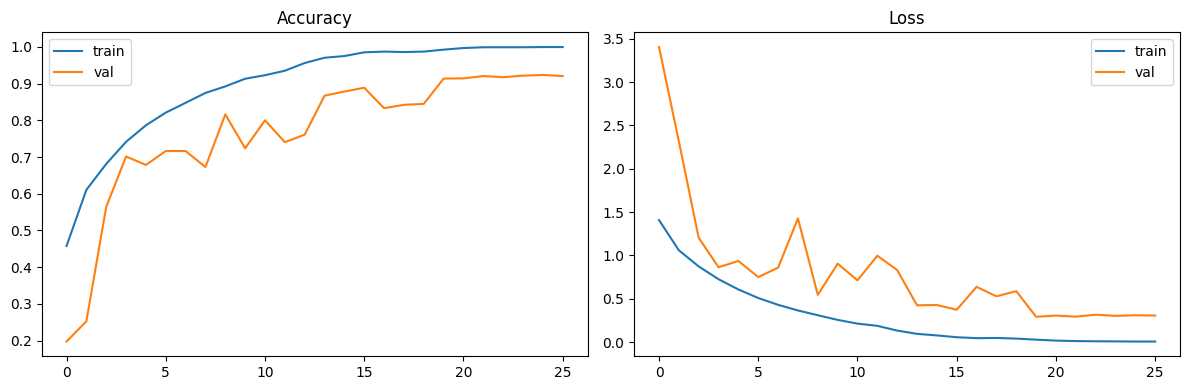

In [12]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="train")
plt.plot(history.history["val_loss"], label="val")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

In [13]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)
print("Test loss:", test_loss)
print("Test accuracy:", test_acc)

pred_probs = model.predict(X_test)
y_pred = np.argmax(pred_probs, axis=1)

print(classification_report(y_test, y_pred, target_names=CLASS_NAMES))

51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 93ms/step - accuracy: 0.8977 - loss: 0.3599
Test loss: 0.3758089542388916
Test accuracy: 0.9019851088523865
51/51 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step
                precision    recall  f1-score   support

     transport       0.93      0.93      0.93       245
         human       0.90      0.87      0.88       362
         alert       0.96      0.90      0.93       225
building_noise       0.92      0.97      0.94       324
       animals       0.86      0.84      0.85       222
        others       0.85      0.89      0.87       234

      accuracy                           0.90      1612
     macro avg       0.90      0.90      0.90      1612
  weighted avg       0.90      0.90      0.90      1612


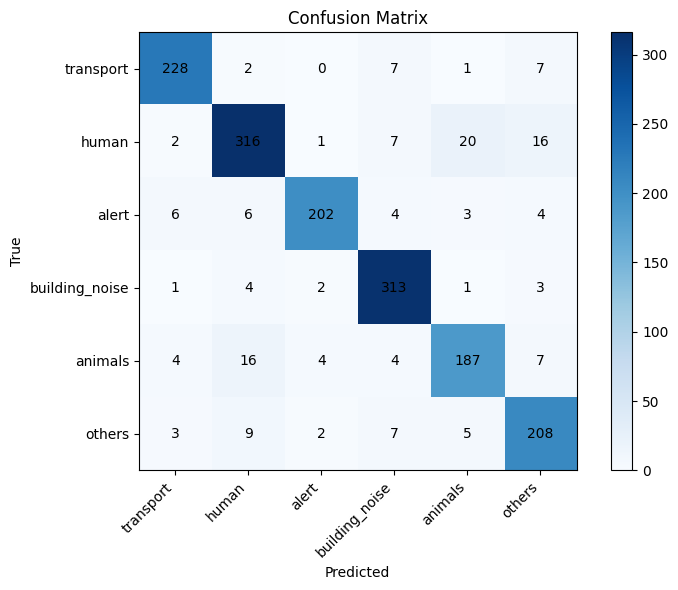

In [14]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45, ha="right")
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
plt.xlabel("Predicted")
plt.ylabel("True")

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [15]:
model.save(ARTIFACTS_DIR / "sound_classifier_final.keras")

metadata = {
    "class_names": CLASS_NAMES,
    "sample_rate": SAMPLE_RATE,
    "duration": DURATION,
    "samples": SAMPLES,
    "n_mels": N_MELS,
    "max_len": MAX_LEN,
    "train_mean": float(train_mean),
    "train_std": float(train_std),
}

with open(ARTIFACTS_DIR / "sound_classifier_metadata.json", "w", encoding="utf-8") as file:
    json.dump(metadata, file, ensure_ascii=False, indent=2)

metadata

{'class_names': ['transport',
  'human',
  'alert',
  'building_noise',
  'animals',
  'others'],
 'sample_rate': 16000,
 'duration': 5,
 'samples': 80000,
 'n_mels': 128,
 'max_len': 157,
 'train_mean': -48.85756301879883,
 'train_std': 23.25877571105957}

In [16]:
def prepare_audio_for_prediction(file_path):
    mel_db = extract_mel(file_path)
    mel_db = (mel_db - train_mean) / train_std
    return mel_db[np.newaxis, ..., np.newaxis]


def predict_audio_class(file_path, confidence_threshold=0.45):
    features = prepare_audio_for_prediction(file_path)
    probs = model.predict(features, verbose=0)[0]
    class_id = int(np.argmax(probs))
    confidence = float(probs[class_id])
    label = ID_TO_CLASS[class_id]

    if confidence < confidence_threshold:
        label = "others"

    return {
        "file": str(file_path),
        "label": label,
        "raw_label": ID_TO_CLASS[class_id],
        "confidence": confidence,
        "probabilities": {CLASS_NAMES[i]: float(probs[i]) for i in range(NUM_CLASSES)},
    }


user_audio_folder = Path("UrbanSound8K/Test/user_audio")

if user_audio_folder.exists():
    for file_path in sorted(user_audio_folder.glob("*.wav")):
        result = predict_audio_class(file_path)
        print(f"{file_path.name} -> {result['label']} ({result['confidence']:.2f})")

auto-volkswagen-engine-at-low-speed-entry-outside.wav -> transport (1.00)
distant-calm-measured-sound-of-a-running-car-engine.wav -> transport (0.98)
engine-start-and-sound.wav -> others (0.73)
Recording (11).wav -> human (0.87)
Recording (12).wav -> human (1.00)
Recording (13).wav -> animals (0.97)
Recording (14).wav -> animals (0.99)
Recording (15).wav -> human (0.93)
Recording (16).wav -> human (0.79)
Recording (17).wav -> others (0.74)
Recording (18).wav -> others (0.79)
Recording (19).wav -> others (0.86)
Recording (20).wav -> others (0.99)
